**Ridge Regression**
**Goal:**
1. Understand overfitting
2. Apply Ridge Regression
3. See how regularization controls model complexity

**Ridge Regression adds a penalty to large weights.**

In [1]:
# importing nesessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Create Non-Linear Data 
#We intentionally create data that can overfit.

np.random.seed(42)

X = np.linspace(0, 10, 100)

y = (
    0.5 * X**3
    - 4 * X**2
    + 10 * X
    + np.random.randn(100) * 20
)

X = X.reshape(-1, 1)

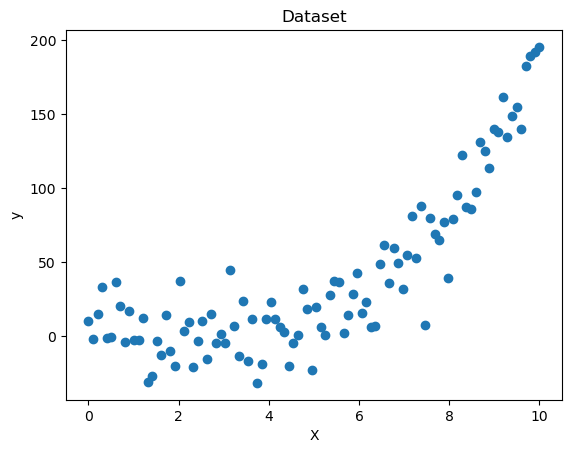

In [4]:
plt.scatter(X, y)

plt.title("Dataset")
plt.xlabel("X")
plt.ylabel("y")

plt.show()

## Observation

The relationship is not linear.

We will use polynomial features to capture the curve.

In [5]:
poly = PolynomialFeatures(degree=10)

X_poly = poly.fit_transform(X)

In [6]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [8]:
# Evaluate Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MSE :", mse_lr)
print("R2  :", r2_lr)

Linear Regression
MSE : 326.91276848894864
R2  : 0.8191155004278097


In [9]:
ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.49068e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [10]:
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MSE :", mse_ridge)
print("R2  :", r2_ridge)

Ridge Regression
MSE : 255.42641837477785
R2  : 0.8586696993243917


In [11]:
print("Largest Linear Coefficient:")
print(np.max(np.abs(lr.coef_)))

print()

print("Largest Ridge Coefficient:")
print(np.max(np.abs(ridge.coef_)))

Largest Linear Coefficient:
669.3153530082299

Largest Ridge Coefficient:
2.368739705550148


## Ridge Penalty

Large weights are penalized.

As λ increases:

- coefficients become smaller
- model becomes simpler
- overfitting decreases

In [13]:
# Create smooth X values for plotting

X_plot = np.linspace(0, 10, 500).reshape(-1, 1)

X_plot_poly = poly.transform(X_plot)

In [14]:
# Linear Regression Predictions
y_plot_lr = lr.predict(X_plot_poly)

# Ridge Regression Predictions
y_plot_ridge = ridge.predict(X_plot_poly)

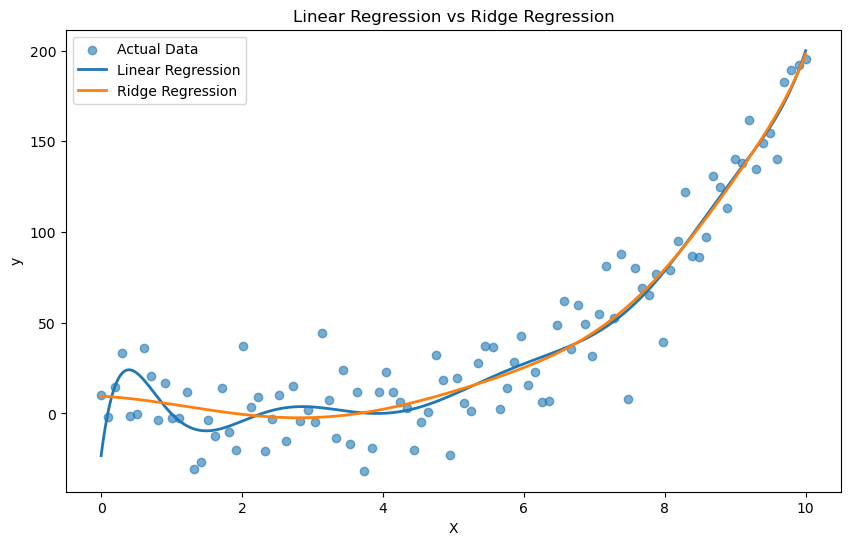

In [15]:
plt.figure(figsize=(10, 6))

# Original Data
plt.scatter(X, y, alpha=0.6, label="Actual Data")

# Linear Regression
plt.plot(
    X_plot,
    y_plot_lr,
    linewidth=2,
    label="Linear Regression"
)

# Ridge Regression
plt.plot(
    X_plot,
    y_plot_ridge,
    linewidth=2,
    label="Ridge Regression"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression vs Ridge Regression")

plt.legend()

plt.show()

## Learned Curves

Linear Regression:
- Large coefficients
- Can overfit

Ridge Regression:
- Penalizes large coefficients
- Produces smoother curves
- Better generalization